**1. Upload the Dataset**
Run this cell to upload your diabetes_unclean.csv file directly to the Colab environment:

In [1]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_unclean1.csv to diabetes_unclean1.csv


**2. The Training & Cleaning Script**
Paste this into a new cell. This follows all the assignment instructions: data cleaning, visualization, and model training.

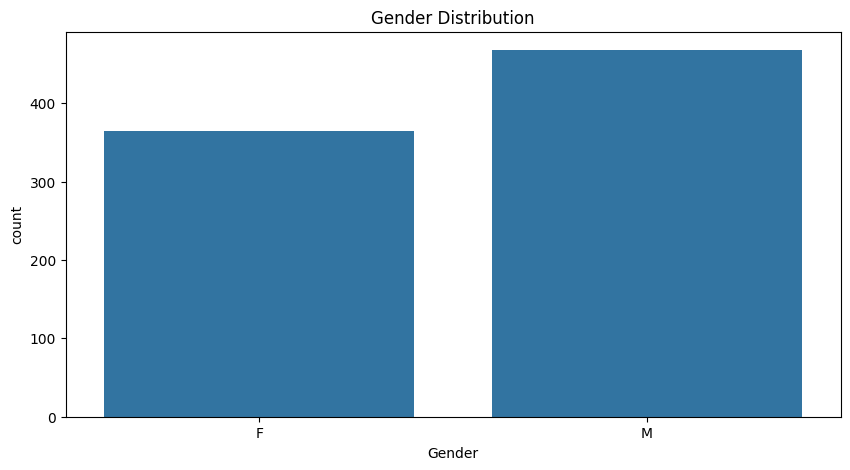

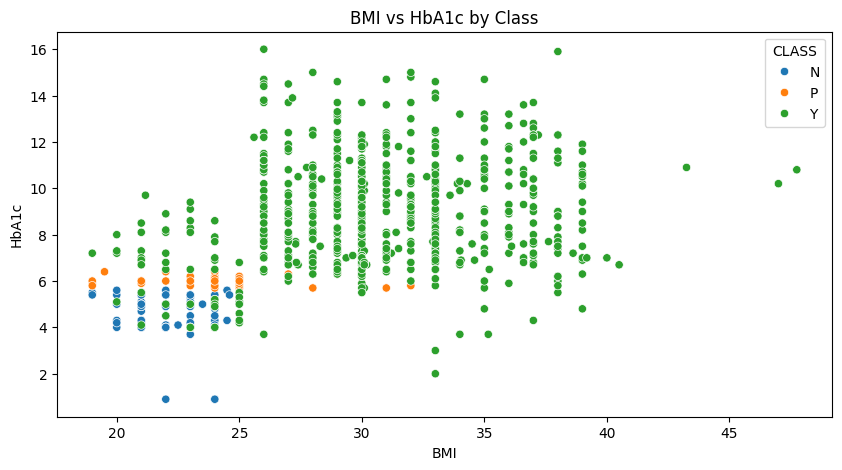

Model Accuracy: 0.976

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        34
           1       0.77      1.00      0.87        10
           2       0.99      0.99      0.99       206

    accuracy                           0.98       250
   macro avg       0.92      0.97      0.94       250
weighted avg       0.98      0.98      0.98       250



['diabetes_model.pkl']

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load and Clean
df = pd.read_csv(next(iter(uploaded.keys())))

# Drop ID and No_Pation
df = df.drop(columns=['ID', 'No_Pation'], errors='ignore')

# Fix Gender misspellings (e.g., 'f' to 'F')
df['Gender'] = df['Gender'].str.strip().str.upper()

# Handle Missing Values
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

# Remove Duplicates
df = df.drop_duplicates()

# 2. Exploratory Data Analysis (Visuals)
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='BMI', y='HbA1c', hue='CLASS')
plt.title('BMI vs HbA1c by Class')
plt.show()

# 3. Encoding & Model Training
# One-hot encode Gender, Label encode CLASS
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)
le = LabelEncoder()
df_encoded['CLASS'] = le.fit_transform(df_encoded['CLASS'])

X = df_encoded.drop('CLASS', axis=1)
y = df_encoded['CLASS']

# Save column names (CRITICAL for FastAPI later)
joblib.dump(X.columns.tolist(), 'training_columns.pkl')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Training Decision Tree
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Save the model
joblib.dump(model, 'diabetes_model.pkl')